In [116]:

import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Adjust display settings for wider output
pd.set_option('display.width', 300)  # Increase the display width
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 10)  # Limit rows displayed for clarity


df = pd.read_csv("/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/enhanced_dataset.csv")

df.head()



,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional,hour_of_day,day_of_week,is_weekend,month_of_year,season,renewable_ratio,fossil_ratio,wind_total,solar_wind_ratio,grid_balance,conventional_vs_renewable,rolling_mean_24h,rolling_std_24h,change_in_load_1h,change_in_wind_1h,change_in_fossil_1h,lag_wind_1h,lag_wind_24h,lag_demand_1h,lag_demand_24h,lead_demand_1h,lead_demand_24h,wind_solar_interaction,hydro_fossil_interaction,renewable_demand_ratio
0,2023-01-01 00:00:00,-5.17,12001.75,38346.00,6575.00,1101.000,4014.25,1275.25,3059.25,28710.50,1.25,129.50,3859.25,2067.50,1817.75,1228.75,0,6,1,1,0,0.831912,0.234007,31769.75,0.000039,26344.25,0.208241,38346.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37777.25,36789.75,39712.1875,298.418011,0.000022
1,2023-01-01 01:00:00,-1.07,14244.25,37777.25,4885.25,1035.125,3993.25,1226.50,3586.00,29305.00,1.00,129.00,3866.50,2052.00,1663.25,1218.25,1,6,1,1,0,0.874098,0.232944,32891.00,0.000030,23533.00,0.198264,38061.625000,402.166982,-568.75,1121.25,-0.001063,31769.75,NaN,38346.00,NaN,36939.75,35423.75,32891.0000,285.706344,0.000023
2,2023-01-01 02:00:00,-1.47,13897.50,36939.75,3830.25,1595.875,3967.25,1222.50,3842.25,29266.00,1.25,129.00,3860.25,2034.25,1666.75,1211.50,2,6,1,1,0,0.899803,0.237488,33108.25,0.000038,23042.25,0.196763,37687.666667,707.392144,-837.50,217.25,0.004544,32891.00,NaN,37777.25,NaN,35932.50,35284.25,41385.3125,290.329168,0.000024
3,2023-01-01 03:00:00,-5.08,12277.25,35932.50,5459.75,1900.125,3973.00,1223.25,3463.25,27008.50,1.00,129.00,3864.75,2037.00,1659.50,1211.75,3,6,1,1,0,0.851645,0.244152,30471.75,0.000033,23655.25,0.211220,37248.875000,1050.597419,-1007.25,-2636.50,0.006664,33108.25,NaN,36939.75,NaN,35486.25,36058.50,30471.7500,298.659215,0.000024
4,2023-01-01 04:00:00,-4.49,12179.00,35486.25,5583.75,1994.500,3996.50,1244.00,3462.25,26438.75,1.50,128.25,3841.00,2040.25,1644.50,1214.25,4,6,1,1,0,0.846264,0.246293,29901.00,0.000050,23307.25,0.213368,36896.350000,1203.821241,-446.25,-570.75,0.002140,30471.75,NaN,35932.50,NaN,35647.25,37796.00,44851.5000,306.387967,0.000024


In [117]:
# Check for missing values
print(df.isnull().sum())

timestamp                    0
energy_price                 0
net_export                   0
total_grid_load              0
residual_load                0
                            ..
lead_demand_1h               1
lead_demand_24h             24
wind_solar_interaction       0
hydro_fossil_interaction     0
renewable_demand_ratio       0
Length: 41, dtype: int64


In [118]:
df.dtypes

timestamp                    object
energy_price                float64
net_export                  float64
total_grid_load             float64
residual_load               float64
                             ...   
lead_demand_1h              float64
lead_demand_24h             float64
wind_solar_interaction      float64
hydro_fossil_interaction    float64
renewable_demand_ratio      float64
Length: 41, dtype: object

In [119]:
# Convert timestamp to a datetime data type
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [120]:
df.dtypes

timestamp                   datetime64[ns]
energy_price                       float64
net_export                         float64
total_grid_load                    float64
residual_load                      float64
                                 ...      
lead_demand_1h                     float64
lead_demand_24h                    float64
wind_solar_interaction             float64
hydro_fossil_interaction           float64
renewable_demand_ratio             float64
Length: 41, dtype: object

In [121]:
# df.fillna(df.mean(), inplace=True)
df.fillna(df.interpolate(), inplace=True)
print(df.isnull().sum())

timestamp                   0
energy_price                0
net_export                  0
total_grid_load             0
residual_load               0
                           ..
lead_demand_1h              0
lead_demand_24h             0
wind_solar_interaction      0
hydro_fossil_interaction    0
renewable_demand_ratio      0
Length: 41, dtype: int64


In [122]:
df.describe()

,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional,hour_of_day,day_of_week,is_weekend,month_of_year,season,renewable_ratio,fossil_ratio,wind_total,solar_wind_ratio,grid_balance,conventional_vs_renewable,rolling_mean_24h,rolling_std_24h,change_in_load_1h,change_in_wind_1h,change_in_fossil_1h,lag_wind_1h,lag_wind_24h,lag_demand_1h,lag_demand_24h,lead_demand_1h,lead_demand_24h,wind_solar_interaction,hydro_fossil_interaction,renewable_demand_ratio
count,19056,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19055.000000,19055.000000,19055.000000,19055.000000,19055.000000,19032.000000,19055.000000,19032.000000,19056.000000,19056.000000,1.905600e+04,19056.000000,1.905600e+04
mean,2024-02-02 00:02:16.020151296,89.488131,-1818.428638,53095.537744,30520.445568,1313.543943,4195.979232,1802.363180,2851.400071,13193.042808,6532.011007,118.070280,8595.075317,3957.131573,6596.093409,1293.794684,11.500000,2.997481,0.285894,6.127939,1.388119,0.426553,0.381619,16044.442879,0.228852,54913.966382,0.959348,53083.992272,6893.089210,0.537090,-0.964471,0.000011,16044.582091,16049.221193,53095.774705,53090.740976,53096.074806,53104.912731,7.454405e+07,677.468137,8.253083e-06
min,2023-01-01 00:00:00,-500.000000,-17359.000000,30902.750000,-8185.500000,43.625000,3214.750000,941.250000,0.250000,43.000000,0.250000,69.000000,2493.750000,309.250000,1606.250000,806.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.003095,0.116223,45.375000,0.000006,21723.250000,0.086560,36441.625000,402.166982,-16379.750000,-7066.000000,-0.121152,45.375000,45.375000,30902.750000,30902.750000,30902.750000,30902.750000,3.500000e+02,193.092116,4.690854e-08
25%,2023-07-18 12:45:00,64.717500,-7041.875000,45490.625000,20981.500000,662.500000,3977.187500,1463.750000,1140.750000,4918.125000,2.750000,97.000000,5553.062500,1873.000000,3823.937500,1192.250000,5.750000,1.000000,0.000000,3.000000,0.000000,0.226932,0.269705,6591.250000,0.000229,47217.125000,0.350955,49182.536458,5991.673365,-1532.625000,-649.125000,-0.011365,6590.500000,6585.875000,45490.250000,45482.812500,45491.000000,45525.937500,4.887005e+04,461.688855,4.333898e-06
50%,2024-02-01 23:30:00,90.600000,-2401.000000,53123.750000,30596.000000,1166.312500,4210.500000,1808.250000,2669.125000,10308.625000,146.125000,109.000000,8581.625000,3121.375000,5843.875000,1315.000000,11.500000,3.000000,0.000000,6.000000,1.000000,0.407440,0.368190,13325.875000,0.011579,54609.375000,0.665040,53164.151042,7135.290540,-271.250000,-24.000000,0.000326,13325.000000,13334.750000,53124.750000,53119.000000,53123.750000,53123.750000,1.645532e+06,640.964080,7.645239e-06
75%,2024-08-18 12:15:00,115.772500,2922.625000,60089.750000,39936.125000,1894.656250,4407.000000,2084.500000,4415.500000,19299.937500,10049.937500,134.000000,11247.000000,5446.812500,8471.812500,1392.250000,17.250000,5.000000,1.000000,9.000000,2.000000,0.602375,0.477459,23466.687500,0.451179,63041.000000,1.262683,57505.434896,7894.058886,1107.125000,609.375000,0.010562,23467.375000,23486.500000,60089.750000,60084.562500,60089.750000,60089.750000,9.210895e+07,846.704532,1.124744e-05
max,2025-03-04 23:00:00,936.280000,18759.250000,76026.250000,69048.500000,3977.875000,5017.000000,3113.250000,7899.250000,48023.000000,46848.250000,203.750000,17173.250000,15240.500000,20146.500000,2252.500000,23.000000,6.000000,1.000000,12.000000,3.000000,1.199219,0.836839,52399.000000,0.994560,87396.500000,5.214688,67022.468750,11419.651145,10380.000000,6669.250000,0.130346,52399.000000,52399.000000,76026.250000,76026.250000,76026.250000,76026.250

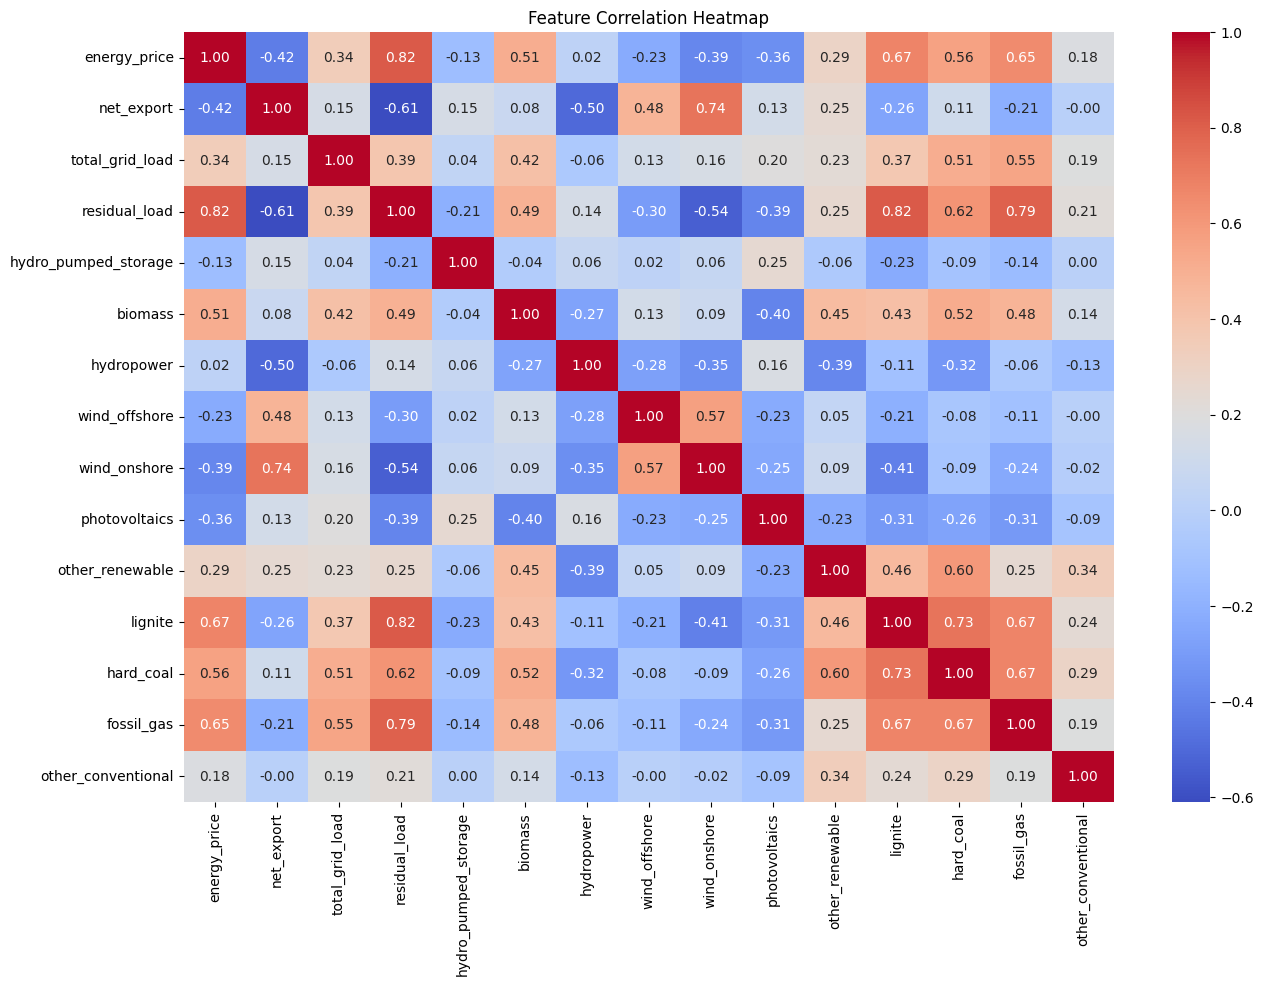

In [123]:
columns= df[[ "energy_price", "net_export", "total_grid_load", "residual_load", 
    "hydro_pumped_storage", "biomass", "hydropower", "wind_offshore", "wind_onshore", 
    "photovoltaics", "other_renewable", "lignite", "hard_coal", "fossil_gas", 
    "other_conventional"]]

plt.figure(figsize=(15,10))
sns.heatmap(columns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


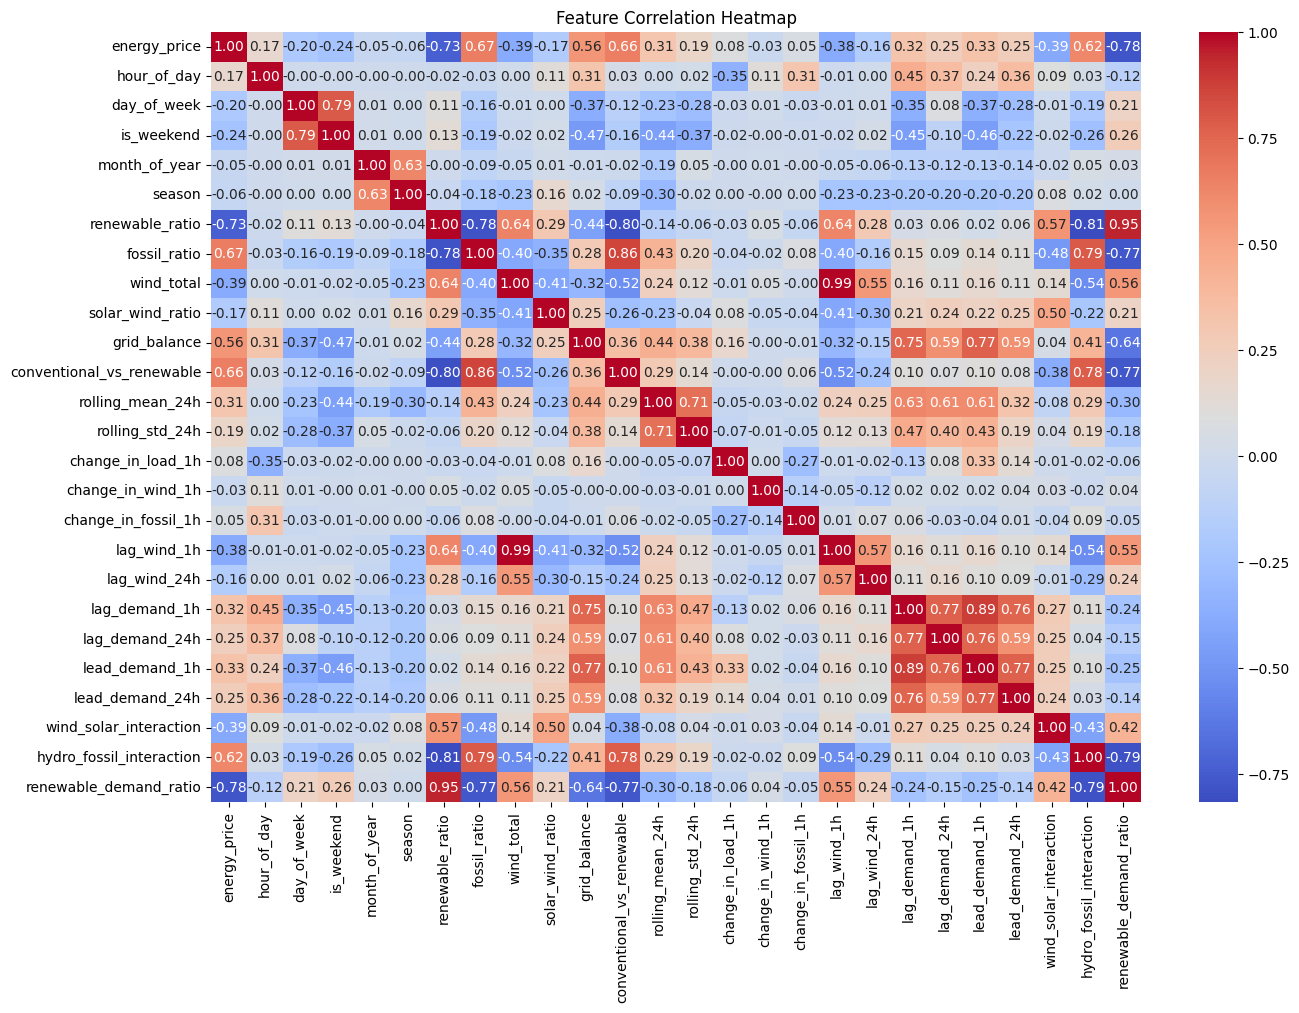

In [124]:
feature_engineer = df[[
      "energy_price", "hour_of_day", "day_of_week", "is_weekend", "month_of_year", 
    "season", "renewable_ratio", "fossil_ratio", "wind_total", "solar_wind_ratio", 
    "grid_balance", "conventional_vs_renewable", "rolling_mean_24h", "rolling_std_24h", 
    "change_in_load_1h", "change_in_wind_1h", "change_in_fossil_1h", "lag_wind_1h", 
    "lag_wind_24h", "lag_demand_1h", "lag_demand_24h", "lead_demand_1h", "lead_demand_24h", 
    "wind_solar_interaction", "hydro_fossil_interaction", "renewable_demand_ratio"
]]

# df_columns = [f"df['{col}']" for col in columns]
# print(df_columns)

plt.figure(figsize=(15,10))
sns.heatmap(feature_engineer.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


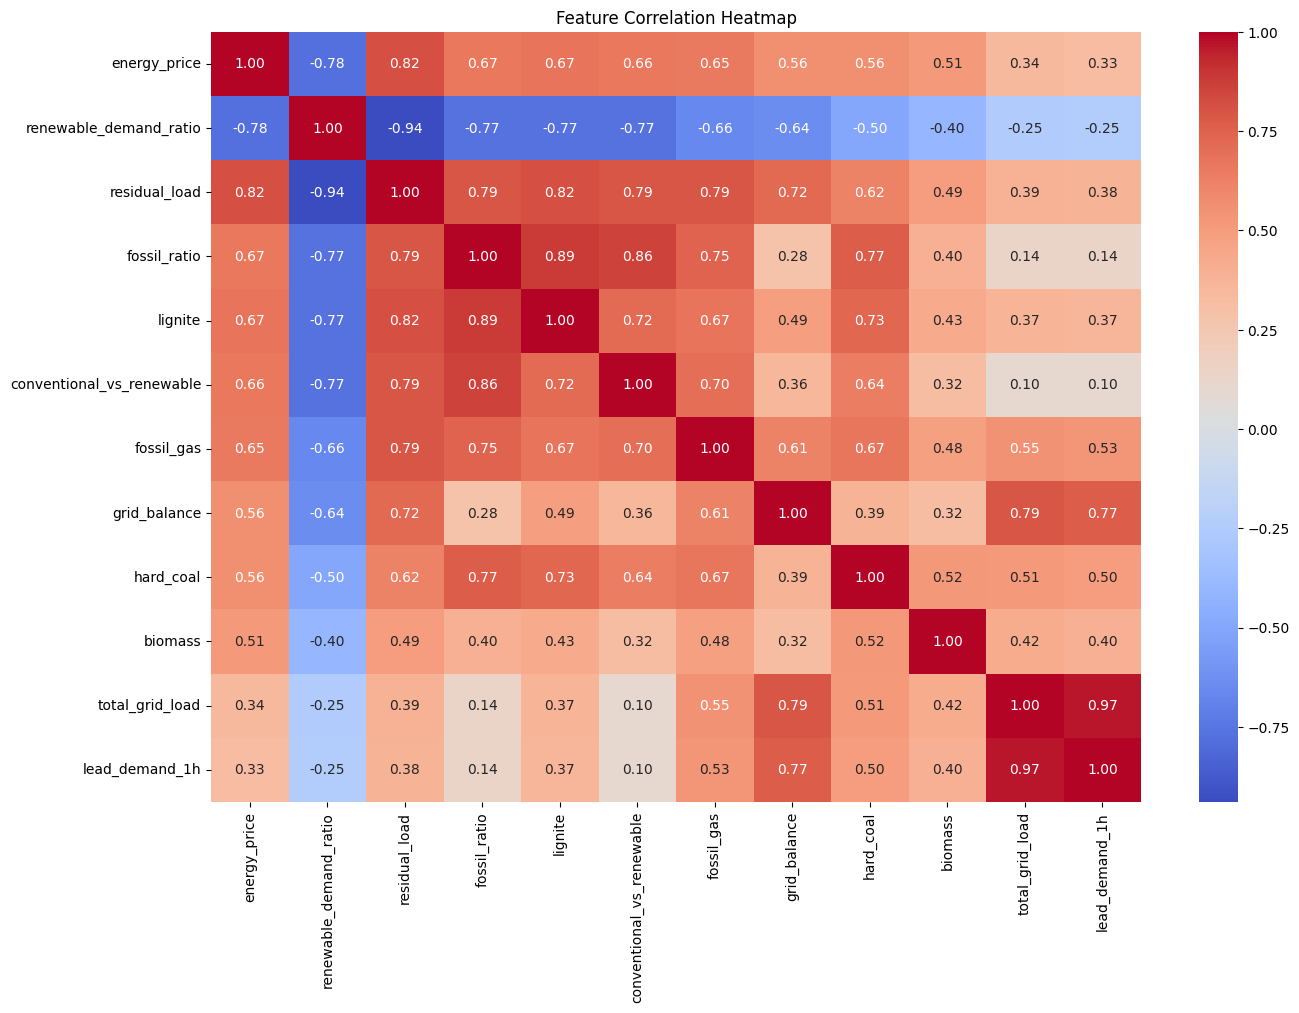

In [125]:
"""These features capture the core dynamics 
of energy prices: the balance between supply 
(renewables vs. fossil fuels) and demand 
(residual_load, total_grid_load), 
as well as temporal trends (lag_demand_1h).
"""

key_features = df[[ 'energy_price', 'renewable_demand_ratio','residual_load', 'fossil_ratio', 
                   'lignite', 'conventional_vs_renewable', 'fossil_gas', 'grid_balance', 'hard_coal',
                    'biomass', 'total_grid_load','lead_demand_1h'
                   ]]

plt.figure(figsize=(15,10))
sns.heatmap(key_features.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
selected_features = [ 'energy_price', 'renewable_demand_ratio','residual_load', 'fossil_ratio', 
                   'lignite', 'conventional_vs_renewable', 'fossil_gas', 'grid_balance', 'hard_coal',
                    'biomass', 'total_grid_load','lead_demand_1h'
                   ]

X